In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Генерация идёт!!!

In [2]:
employees = pd.DataFrame()

In [3]:
employees['id'] = np.linspace(1, 100, num=100, dtype='int')

In [12]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      100 non-null    int32
dtypes: int32(1)
memory usage: 528.0 bytes


In [4]:
employees['name'] = np.random.choice(['Turbo', 'Artur', 'Turik', 'Sasha', 'Anya', 'Tanya', 'Danil', 'Artem', 'Bulat', 'Lexa'], size=100)

In [5]:
employees['department'] = np.random.choice(['IT', 'Audit', 'Sport', 'Business', 'Taxes', 'Banki', 'Technologies', 'Jurisdiction'], size=100)

In [6]:
employees['access_logs'] = np.random.choice(['low', 'medium', 'high', 'admin'], size=100)

In [7]:
employees.head()

,id,name,department,access_logs
0,1,Turbo,IT,low
1,2,Turik,Sport,high
2,3,Anya,Taxes,medium
3,4,Turbo,Technologies,low
4,5,Danil,Technologies,medium


In [33]:
logs = pd.DataFrame()

In [34]:
logs['log_id'] = np.linspace(1, 1000, num=1000, dtype='int')

In [35]:
logs.shape

(1000, 1)

In [36]:
logs['user_id'] = np.random.randint(1, 100, size=1000)

In [37]:
import random
from datetime import datetime, timedelta

def generate_random_datetime(start_year, end_year):
    start = datetime(start_year, 1, 1, 00, 00, 00)
    end = start + timedelta(days=365 * (end_year - start_year + 1))
    random_delta = timedelta(days=random.randint(0, (end - start).days))
    return start + random_delta

print(generate_random_datetime(2025, 2026).date())

2025-05-01


In [39]:
logs['date'] = generate_random_datetime(2025, 2026).date()
logs['date'] = logs['date'].apply(lambda x: generate_random_datetime(2025, 2026).date())

In [40]:
logs.head()

,log_id,user_id,date
0,1,40,2026-08-25
1,2,4,2026-07-21
2,3,1,2025-02-04
3,4,36,2025-08-27
4,5,85,2026-11-07


In [73]:
def gen_ran_time():
    start = datetime(2025, 4, 1, 0, 0, 0)
    end = datetime(2025, 4, 1, 23, 59, 59)

    delta = end - start
    random_seconds = random.randint(0, int(delta.total_seconds()))

    return start + timedelta(seconds=random_seconds)

print(gen_ran_time().time())

22:57:42


In [74]:
logs['time'] = gen_ran_time().time()
logs['time'] = logs['time'].apply(lambda x: gen_ran_time().time())

In [75]:
logs.head()

,log_id,user_id,date,time
0,1,40,2026-08-25,06:48:41
1,2,4,2026-07-21,13:33:59
2,3,1,2025-02-04,13:40:15
3,4,36,2025-08-27,15:32:26
4,5,85,2026-11-07,15:38:58


In [76]:
logs['status'] = np.random.choice(['success', 'failure'], size=1000)

In [77]:
logs.head()

,log_id,user_id,date,time,status
0,1,40,2026-08-25,06:48:41,success
1,2,4,2026-07-21,13:33:59,success
2,3,1,2025-02-04,13:40:15,failure
3,4,36,2025-08-27,15:32:26,failure
4,5,85,2026-11-07,15:38:58,success


In [88]:
changes = pd.DataFrame()

In [89]:
changes['change_id'] = np.linspace(1, 200, num=200, dtype='int')

In [90]:
changes['user_id'] = np.random.randint(1, 100, size=200)

In [91]:
changes['changed_by'] = np.random.choice(['Turbo', 'Artur', 'Turik', 'Sasha', 'Anya', 'Tanya', 'Danil', 'Artem', 'Bulat', 'Lexa'], size=200)

In [92]:
changes['date'] = generate_random_datetime(2025, 2026).date()
changes['date'] = changes['date'].apply(lambda x: generate_random_datetime(2025, 2026).date())

In [93]:
changes['new_level'] = np.random.choice(['low', 'medium', 'high', 'admin'], size=200)

In [94]:
changes.head()

,change_id,user_id,changed_by,date,new_level
0,1,10,Danil,2026-12-20,admin
1,2,55,Danil,2026-11-24,high
2,3,86,Turbo,2025-04-03,high
3,4,7,Danil,2025-08-28,medium
4,5,40,Lexa,2026-05-12,medium


## Проверочка данных

In [2]:
employees = pd.read_csv('employees.csv')
logs = pd.read_csv('logs.csv', parse_dates=['date'])
changes = pd.read_csv('changes.csv', parse_dates=['date'])

In [4]:
print(employees.isnull().sum(), logs.isnull().sum(), changes.isnull().sum())

id             0
name           0
department     0
access_logs    0
dtype: int64 log_id     0
user_id    0
date       0
time       0
status     0
dtype: int64 change_id     0
user_id       0
changed_by    0
date          0
new_level     0
dtype: int64


In [5]:
employees['id'].duplicated().sum()

0

In [7]:
changes['change_id'].duplicated().sum()

0

In [8]:
logs['log_id'].duplicated().sum()

0

## Графики

In [3]:
import plotly.express as px

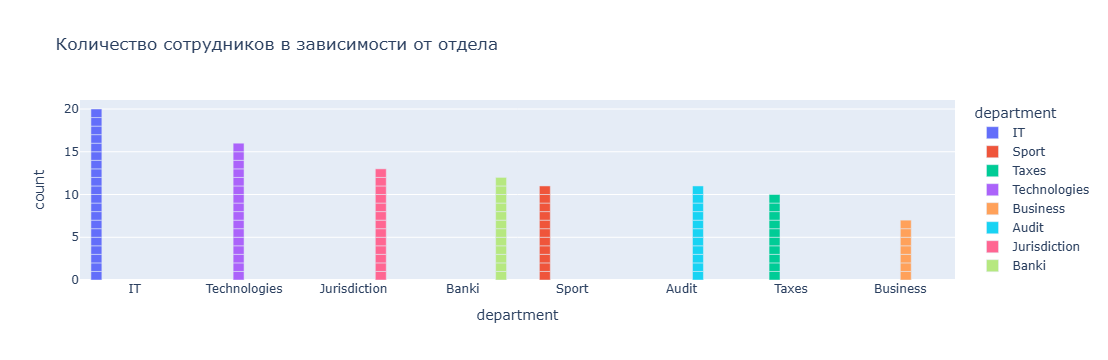

In [16]:
fig = px.bar(employees, x='department', color='department', title='Количество сотрудников в зависимости от отдела')
fig.update_layout(xaxis={'categoryorder': 'total descending'})

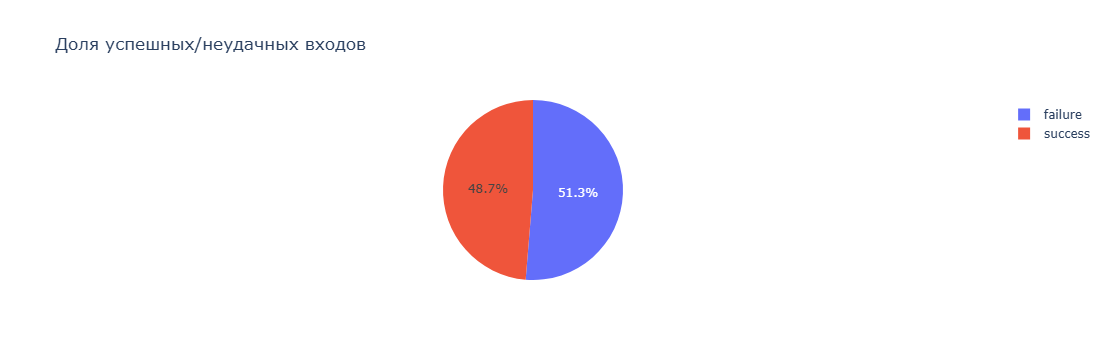

In [31]:
px.pie(logs, names='status', title='Доля успешных/неудачных входов')

In [8]:
groupby_failure = logs[logs['status'] == 'failure'].groupby(pd.Grouper(key='date', freq='W'))['status'].count()

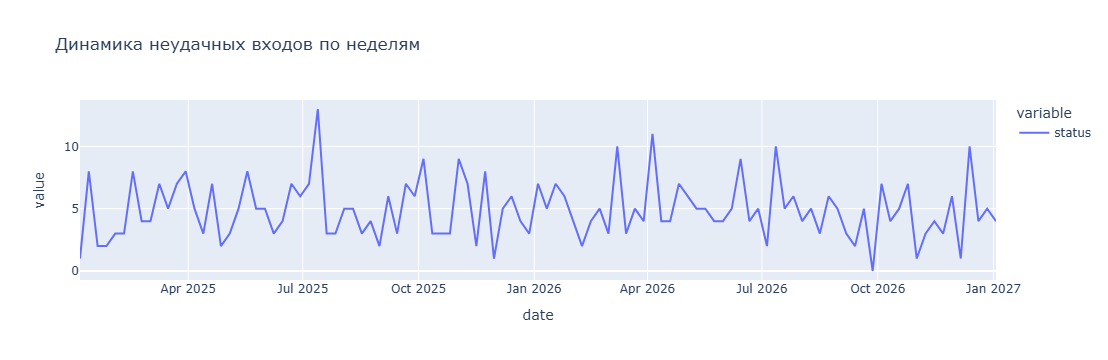

In [12]:
px.line(groupby_failure, title='Динамика неудачных входов по неделям')

In [4]:
changes_with_emp = changes.merge(employees, how='left', left_on='user_id', right_on='id').drop('id', axis=1)
changes_with_emp.head()

,change_id,user_id,changed_by,date,new_level,name,department,access_logs
0,1,10,Danil,2026-12-20,admin,Danil,Taxes,admin
1,2,55,Danil,2026-11-24,high,Sasha,Sport,medium
2,3,86,Turbo,2025-04-03,high,Lexa,Jurisdiction,high
3,4,7,Danil,2025-08-28,medium,Lexa,Technologies,admin
4,5,40,Lexa,2026-05-12,medium,Bulat,Banki,medium


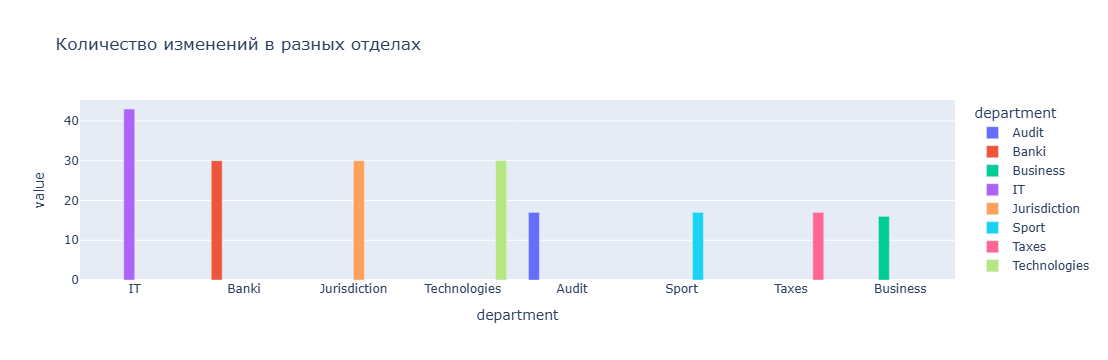

In [25]:
changes_by_department = changes_with_emp.groupby('department')['change_id'].count()
fig = px.bar(changes_by_department, color=changes_by_department.index, title='Количество изменений в разных отделах')
fig.update_layout(xaxis={'categoryorder': 'total descending'})

In [5]:
logs_with_emp = logs.merge(employees, how='left', left_on='user_id', right_on='id').drop('id', axis=1)
logs_with_emp.head()

,log_id,user_id,date,time,status,name,department,access_logs
0,1,40,2026-08-25,06:48:41,success,Bulat,Banki,medium
1,2,4,2026-07-21,13:33:59,success,Turbo,Technologies,low
2,3,1,2025-02-04,13:40:15,failure,Turbo,IT,low
3,4,36,2025-08-27,15:32:26,failure,Anya,Taxes,medium
4,5,85,2026-11-07,15:38:58,success,Artem,Jurisdiction,low


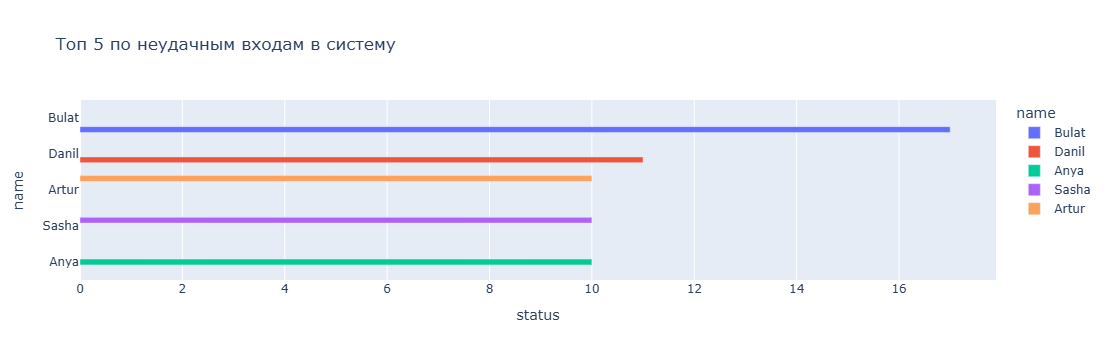

In [16]:
groupby_emp_failure = logs_with_emp[logs_with_emp['status'] == 'failure'].groupby(['user_id', 'name'])['status'].count()
top_groupby_emp_failure = groupby_emp_failure.sort_values(ascending=False).head().reset_index()
fig = px.bar(top_groupby_emp_failure, x='status', y='name', color='name', title='Топ 5 по неудачным входам в систему', orientation='h')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})

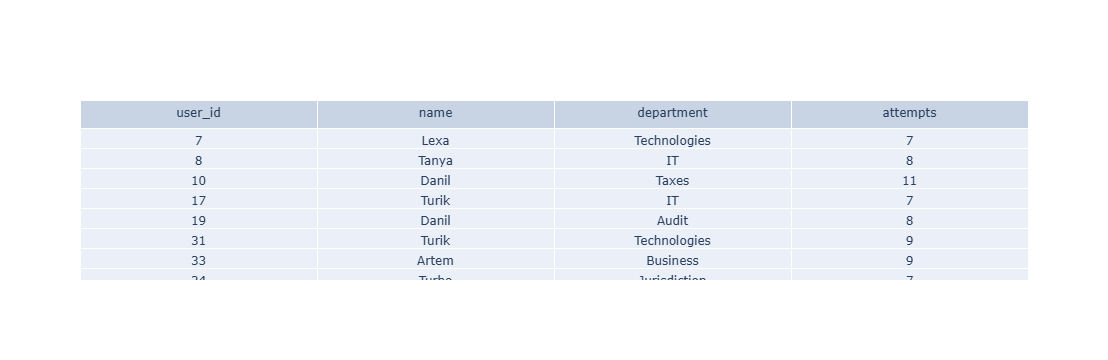

In [64]:
import plotly.graph_objects as go

admin_with_failure = logs_with_emp[(logs_with_emp['status'] == 'failure') & (logs_with_emp['access_logs'] == 'admin')]
admin_with_failure_clean = admin_with_failure.groupby(['user_id', 'name', 'department'])['status'].count().reset_index()
table = admin_with_failure_clean.query('status > 5').rename({'status': 'attempts'}, axis=1)

go.Figure(data=[go.Table(header=dict(values=list(table.columns)), 
                         cells=dict(values=table.values.T.tolist()))])

In [6]:
logs_with_emp[logs_with_emp['department'].isin(['IT', 'Taxes'])]

,log_id,user_id,date,time,status,name,department,access_logs
2,3,1,2025-02-04,13:40:15,failure,Turbo,IT,low
3,4,36,2025-08-27,15:32:26,failure,Anya,Taxes,medium
5,6,14,2026-12-09,08:27:13,success,Artur,Taxes,high
6,7,52,2025-10-26,20:19:31,success,Turbo,IT,low
8,9,58,2025-12-17,02:25:47,failure,Turik,IT,high
...,...,...,...,...,...,...,...,...
985,986,1,2025-03-10,12:56:45,success,Turbo,IT,low
986,987,8,2026-12-23,04:34:45,failure,Tanya,IT,admin
987,988,14,2025-03-30,02:09:15,success,Artur,Taxes,high
992,993,73,2025-04-28,02:04:02,failure,Bulat,Taxes,high


In [11]:
groupby_dep_failure = logs_with_emp[logs_with_emp['status'] == 'failure'].groupby(['department'])['status'].count()
top = groupby_dep_failure.sort_values(ascending=False).head().reset_index().loc[0, 'department']
top

'IT'